# Processing of a resting-state EEG dataset for sleep deprivation

Bad channels are interpolated

## PRE PROCESSING

#### The intention is to provide epochs(4 seconds) to the machine and try predicting if the case is sleep deprivation or normal sleep.

In [3]:
from matplotlib import pyplot as plt
import os
import pandas as pd
import numpy as np
from scipy import signal
import mne
import mne_icalabel
from mne.preprocessing import ICA
from autoreject import Ransac  
from mne_icalabel import label_components
from tqdm import tqdm_notebook
%matplotlib inline

In [4]:
# lists to collect data
X_list = []
y_list = []
data_NS_list =[]
data_SD_list =[]
epochs_NS_list = []
epochs_SD_list = []

In [ ]:
n_epochs = 0
for i in range(1, 72):
    if i == 28 or i== 1 or i== 44 or i==39 or i==43:
        continue  # Skip participants due to missing data
    for j in range(1, 3):
        
        #Define file path
        file_path = f'D:\\BCI\\TASKS\\Task-8\\ds004902_data\\sub-{i:02d}\\ses-{j}\\eeg\\sub-{i:02d}_ses-{j}_task-eyesopen_eeg.set'#The d indicates that the value is a decimal integer, while the 02 specifies that the output should be padded with leading zeros if necessary to reach a width of two characters.
        epochs_file = f'D:\\BCI\\TASKS\\Task-8\\processed_epochs\\sub-{i:02d}_ses-{j}_epochs.fif'  # Path to save/load processed epochs
        
        
        if os.path.exists(epochs_file):
            print(f"Loading processed epochs from {epochs_file}")
            epochs = mne.read_epochs(epochs_file, preload=True)
        else:
            print(f"\nProcessing: {file_path}\n")

            #Define EEG channels
            eeg_channels = ["Fp1", "AF3", "AF7", "Fz", "F1", "F3", "F5", "F7","FC1", "FC3", "FC5", "FT7","Cz", "C1", "C3", "C5", "T7","CP1", "CP3", "CP5", "TP7", "TP9","Pz", "P1", "P3", "P5", "P7","PO3", "PO7", "Oz", "O1","Fpz", "Fp2", "AF4", "AF8","F2", "F4", "F6", "F8","FC2", "FC4", "FC6", "FT8","C2", "C4", "C6", "T8","CPz", "CP2", "CP4", "CP6","TP8", "TP10","P2", "P4", "P6", "P8","POz", "PO4", "PO8", "O2"]
            
            #Load EEG data
            raw = mne.io.read_raw_eeglab(file_path, preload=True)
            eeg_raw=raw.pick(mne.pick_channels(raw.info['ch_names'], include=eeg_channels))
            
            #Montage setting
            montage = mne.channels.make_standard_montage('standard_1020')
            eeg_raw.set_montage(montage)

            #Filtering
            eeg_raw.filter(1., 40.)#, fir_design='firwin')

            #Average Referencing
            eeg_raw.set_eeg_reference('average')

            #EPOCHING
            epochs = mne.make_fixed_length_epochs(eeg_raw, duration=4.0, overlap=0.0,preload=True)

            #RANSAC for bad channel detection
            ransac = Ransac(verbose=False, n_jobs=1)
            ransac.fit(epochs)
            epochs.info['bads'].extend(ransac.bad_chs_)   

            #interpolate bad channels
            epochs.interpolate_bads(reset_bads=True)
            
            #ICA for artifact removal
            ica = mne.preprocessing.ICA(n_components=20, method='infomax', fit_params=dict(extended=True), random_state=42, max_iter=1000)
            ica.fit(epochs)

            ic_labels = label_components(epochs, ica, method='iclabel')
            exclude_idx = []
            for idx, label in enumerate(ic_labels["labels"]):
                if label not in ["brain","other","muscle artifact"] and ic_labels["y_pred_proba"][idx] > 0.5:
                    exclude_idx.append(idx)

            ica.apply(epochs,exclude= exclude_idx)           

            # Save processed epochs
            os.makedirs(os.path.dirname(epochs_file), exist_ok=True) #creates the necessary directories for the file path if they don't exist.
            epochs.save(epochs_file, overwrite=True)
            print(f"Saved processed epochs to {epochs_file}")

        if j==1:
            labels = 0
        elif j==2:
            labels = 1
        labels = pd.DataFrame({'label': [labels]*len(epochs)})
        
        # Extract data and labels
        data = epochs.get_data()  # shape: (n_epochs, n_channels, n_times)

        #if (i == 39 or i == 43) and j == 2:
        #    data = signal.decimate(data, 10, axis=2) # Downsample by a factor of 10 to match time points.

        epoch_labels = labels['label'].values  
        
        if i <= 71:  
            X_list.append(data)
            y_list.append(epoch_labels)

        if j==1:
            data_NS_list.append(data)
            epochs_NS_list.append(epochs)
        elif j==2:
            data_SD_list.append(data)
            epochs_SD_list.append(epochs)

# After the loop, concatenate into arrays
X= np.concatenate(X_list, axis=0)
y = np.concatenate(y_list, axis=0)
data_SD = np.concatenate(data_SD_list, axis=0)
data_NS = np.concatenate(data_NS_list, axis=0)


Loading processed epochs from D:\BCI\TASKS\Task-8\processed_epochs\sub-02_ses-1_epochs.fif
Reading D:\BCI\TASKS\Task-8\processed_epochs\sub-02_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata
75 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:\BCI\TASKS\Task-8\processed_epochs\sub-02_ses-2_epochs.fif
Reading D:\BCI\TASKS\Task-8\processed_epochs\sub-02_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available


C:\Users\suvan\AppData\Local\Temp\ipykernel_5560\2940282627.py:14: RuntimeWarning: This filename (D:\BCI\TASKS\Task-8\processed_epochs\sub-02_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\suvan\AppData\Local\Temp\ipykernel_5560\2940282627.py:14: RuntimeWarning: This filename (D:\BCI\TASKS\Task-8\processed_epochs\sub-02_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)


Not setting metadata
75 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:\BCI\TASKS\Task-8\processed_epochs\sub-03_ses-1_epochs.fif
Reading D:\BCI\TASKS\Task-8\processed_epochs\sub-03_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata
75 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:\BCI\TASKS\Task-8\processed_epochs\sub-03_ses-2_epochs.fif
Reading D:\BCI\TASKS\Task-8\processed_epochs\sub-03_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available


C:\Users\suvan\AppData\Local\Temp\ipykernel_5560\2940282627.py:14: RuntimeWarning: This filename (D:\BCI\TASKS\Task-8\processed_epochs\sub-03_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\suvan\AppData\Local\Temp\ipykernel_5560\2940282627.py:14: RuntimeWarning: This filename (D:\BCI\TASKS\Task-8\processed_epochs\sub-03_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)


Not setting metadata
75 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:\BCI\TASKS\Task-8\processed_epochs\sub-04_ses-1_epochs.fif
Reading D:\BCI\TASKS\Task-8\processed_epochs\sub-04_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata
75 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:\BCI\TASKS\Task-8\processed_epochs\sub-04_ses-2_epochs.fif
Reading D:\BCI\TASKS\Task-8\processed_epochs\sub-04_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available


...

C:\Users\suvan\AppData\Local\Temp\ipykernel_5560\2940282627.py:14: RuntimeWarning: This filename (D:\BCI\TASKS\Task-8\processed_epochs\sub-71_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)


Not setting metadata
75 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:\BCI\TASKS\Task-8\processed_epochs\sub-71_ses-2_epochs.fif
Reading D:\BCI\TASKS\Task-8\processed_epochs\sub-71_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available


C:\Users\suvan\AppData\Local\Temp\ipykernel_5560\2940282627.py:14: RuntimeWarning: This filename (D:\BCI\TASKS\Task-8\processed_epochs\sub-71_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)


Not setting metadata
75 matching events found
No baseline correction applied
0 projection items activated


MemoryError: Unable to allocate 4.47 GiB for an array with shape (4915, 61, 2000) and data type float64

In [ ]:
print(X.shape)
print(y.shape)
print("\n")
print(data_SD.shape)
print(data_NS.shape)
print("\n")
print(X)
print(y)

(9852, 61, 2000)
(9852,)


(4915, 61, 2000)
(4937, 61, 2000)


(4937, 61, 2000)
(4915, 61, 2000)


[[[-2.10158294e-09 -1.52326166e-06 -3.03124332e-06 ... -8.16872976e-06
   -7.34901522e-06 -6.54486893e-06]
  [-2.18218588e-09  3.74633399e-09 -2.35648676e-07 ... -9.81649110e-06
   -9.60330579e-06 -9.10861871e-06]
  [-1.21815200e-09 -7.63305901e-07 -1.65087533e-06 ... -9.88726327e-06
   -9.34811780e-06 -8.64765642e-06]
  ...
  [ 4.75879321e-10  1.10838330e-06  2.37083744e-06 ...  1.19887371e-05
    1.19182987e-05  1.17553644e-05]
  [ 5.29350013e-10  3.34780811e-07  9.42897019e-07 ...  7.54408167e-06
    8.36059473e-06  9.51837728e-06]
  [ 5.87022804e-10  1.91172611e-06  3.82202887e-06 ...  1.01201086e-05
    8.83173463e-06  7.20434950e-06]]

 [[-5.96401070e-06 -5.74406193e-06 -5.92225455e-06 ...  1.46702134e-06
    3.01690721e-06  4.18573808e-06]
  [-8.51382349e-06 -7.99602507e-06 -7.69655655e-06 ...  3.96079444e-06
    5.37075757e-06  6.40645645e-06]
  [-7.95554302e-06 -7.42427347e-06 -7

## Balancing the no of epochs

In [ ]:
min_length = min(len(data_NS), len(data_SD))
print("Minimum length for balancing:", min_length)
def balance_data(data_array, target_length):
    # If this is the larger array, sample it down
    if len(data_array) > target_length:
        # random_state=42 ensures you get the same 'random' choice every time (reproducible)
        indices = np.random.choice(len(data_array), target_length, replace=False)
        return data_array[indices]
    return data_array

Minimum length for balancing: 4915


In [ ]:
data_NS = balance_data(data_NS, min_length)
data_SD = balance_data(data_SD, min_length)
print("Balanced data_NS shape:", data_NS.shape)
print("Balanced data_SD shape:", data_SD.shape)

Balanced data_NS shape: (4915, 61, 2000)
Balanced data_SD shape: (4915, 61, 2000)


In [ ]:
#no of epoches obtained
n_epochs = data_NS.shape[0] + data_SD.shape[0]
print("Total number of epochs:", n_epochs)

Total number of epochs: 9830


In [ ]:
data_NS_averaged = data_NS.mean(axis=0) 
data_SD_averaged = data_SD.mean(axis=0) 
data_NS_averaged.shape , data_SD_averaged.shape

((61, 2000), (61, 2000))

In [ ]:
eeg_data_NS = data_NS_averaged
sfreq= 500
ch_names = ["Fp1", "AF3", "AF7", "Fz", "F1", "F3", "F5", "F7","FC1", "FC3", "FC5", "FT7","Cz", "C1", "C3", "C5", "T7","CP1", "CP3", "CP5", "TP7", "TP9","Pz", "P1", "P3", "P5", "P7","PO3", "PO7", "Oz", "O1","Fpz", "Fp2", "AF4", "AF8","F2", "F4", "F6", "F8","FC2", "FC4", "FC6", "FT8","C2", "C4", "C6", "T8","CPz", "CP2", "CP4", "CP6","TP8", "TP10","P2", "P4", "P6", "P8","POz", "PO4", "PO8", "O2"]
n_channels = len(ch_names)
ch_types = ['eeg'] * n_channels

In [ ]:
eeg_data_SD = data_SD_averaged
sfreq= 500
ch_names = ["Fp1", "AF3", "AF7", "Fz", "F1", "F3", "F5", "F7","FC1", "FC3", "FC5", "FT7","Cz", "C1", "C3", "C5", "T7","CP1", "CP3", "CP5", "TP7", "TP9","Pz", "P1", "P3", "P5", "P7","PO3", "PO7", "Oz", "O1","Fpz", "Fp2", "AF4", "AF8","F2", "F4", "F6", "F8","FC2", "FC4", "FC6", "FT8","C2", "C4", "C6", "T8","CPz", "CP2", "CP4", "CP6","TP8", "TP10","P2", "P4", "P6", "P8","POz", "PO4", "PO8", "O2"]
n_channels = len(ch_names)
ch_types = ['eeg'] * n_channels

In [ ]:
info_NS = mne.create_info(ch_names = ch_names, sfreq= sfreq, ch_types= ch_types)
raw_NS= mne.io.RawArray(data=eeg_data_NS,info=info_NS)

info_SD = mne.create_info(ch_names = ch_names, sfreq= sfreq, ch_types= ch_types)
raw_SD= mne.io.RawArray(data=eeg_data_SD,info=info_SD)

Creating RawArray with float64 data, n_channels=61, n_times=2000
    Range : 0 ... 1999 =      0.000 ...     3.998 secs
Ready.
Creating RawArray with float64 data, n_channels=61, n_times=2000
    Range : 0 ... 1999 =      0.000 ...     3.998 secs
Ready.


In [ ]:
montage = mne.channels.make_standard_montage('standard_1020')
raw_NS.set_montage(montage)

<RawArray | 61 x 2000 (4.0 s), ~1.0 MiB, data loaded>

In [ ]:
montage = mne.channels.make_standard_montage('standard_1020')
raw_SD.set_montage(montage)

<RawArray | 61 x 2000 (4.0 s), ~1.0 MiB, data loaded>

Effective window size : 4.000 (s)


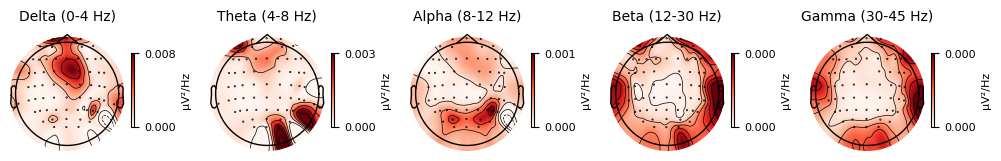

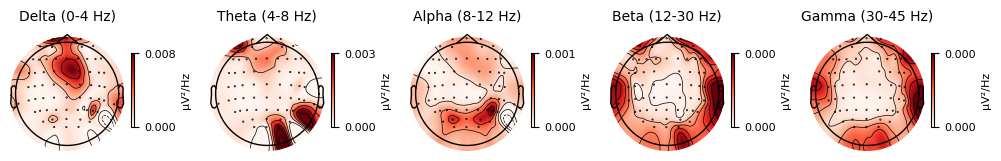

In [ ]:
raw_NS.compute_psd().plot_topomap()

Effective window size : 4.000 (s)


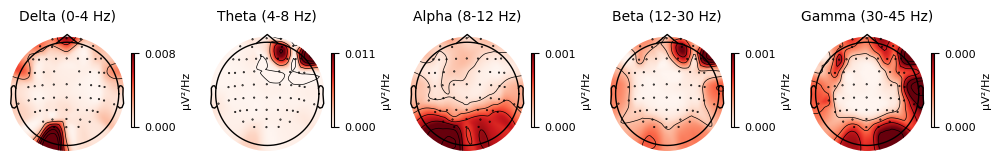

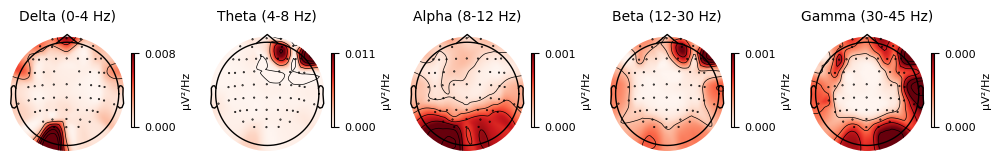

In [ ]:
raw_SD.compute_psd().plot_topomap()